# Label Distribution Landscape

This notebook visualizes the relationship between event log properties (number of unique activities, average trace length) and the ground truth label distribution across all datasets.

**Visualization**: Each dataset is represented by:
- Position based on log properties (activities × trace length)
- Pie chart showing the distribution of best alignment heuristics

In [26]:
import sys
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
from collections import Counter
from tqdm import tqdm
from adjustText import adjust_text

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from features import CompositeFeatureExtractor
from models.evaluator_csv import HEURISTIC_ALIASES, get_heuristic_alias

## Configuration

In [27]:
# Paths
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
RUNS_DIR = PROJECT_ROOT / "cache" /".runs"
RUNS_SYNTHETIC_DIR = PROJECT_ROOT / "cache" / ".runs_synthetic"

# Color scheme for heuristics (consistent across all plots)
HEURISTIC_COLORS = {
    'Dijkstra': '#e41a1c',
    'A*-ILP': '#377eb8',
    'A*': '#4daf4a',
    'RequiredModelMove': '#984ea3',
    'RemainingActivities': '#ff7f00',
}

# Feature indices (from CompositeFeatureExtractor)

_fe = CompositeFeatureExtractor()
feature_names = _fe.feature_names

# Find indices for the features we need
FEATURE_IDX_TRANSITIONS = feature_names.index('model_n_transitions')
FEATURE_IDX_TRACE_LENGTH = feature_names.index('trace_length')

print(f"\nData directory: {DATA_DIR.absolute()}")
print(f"Runs directory: {RUNS_DIR.absolute()}")
print(f"Synthetic runs directory: {RUNS_SYNTHETIC_DIR.absolute()}")

print(f"Data directory: {DATA_DIR.absolute()}")
print(f"Runs directory: {RUNS_DIR.absolute()}")
print(f"Synthetic runs directory: {RUNS_SYNTHETIC_DIR.absolute()}")


Data directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/data
Runs directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/cache/.runs
Synthetic runs directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/cache/.runs_synthetic
Data directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/data
Runs directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/cache/.runs
Synthetic runs directory: /Users/michael/Daten/Master/Praktikum_Process_Mining/pm_ws25/cache/.runs_synthetic


## Dataset Mapping

Create mapping from UUID to human-readable dataset name.

In [28]:
def build_dataset_mapping():
    """
    Build mapping from UUID to dataset name by scanning data directory.
    
    Returns:
        dict: {uuid: dataset_name}
    """
    mapping = {}
    
    for uuid_dir in DATA_DIR.iterdir():
        if not uuid_dir.is_dir():
            continue
        
        uuid = uuid_dir.name
        
        # Find the first .xes or .csv file
        for file in uuid_dir.iterdir():
            if file.suffix in ['.xes', '.csv']:
                # Use filename without extension as dataset name
                name = file.stem.replace('%20', ' ')
                mapping[uuid] = name
                break
    
    return mapping

dataset_mapping = build_dataset_mapping()
print(f"Found {len(dataset_mapping)} datasets:")
for uuid, name in sorted(dataset_mapping.items(), key=lambda x: x[1])[:10]:
    print(f"  {uuid[:8]}...: {name}")
print(f"  ... and {len(dataset_mapping) - 10} more" if len(dataset_mapping) > 10 else "")

Found 29 datasets:
  5f3067df...: BPI Challenge 2017
  3301445f...: BPI Challenge 2018
  01345ac4...: BPI2016_Clicks_Logged_In
  9b99a146...: BPI2016_Clicks_NOT_Logged_In
  e30ba0c8...: BPI2016_Complaints
  2b02709f...: BPI2016_Questions
  c3f3ba2d...: BPI2016_Werkmap_Messages
  a0addfda...: BPIC15_1
  63a8435a...: BPIC15_2
  ed445cdd...: BPIC15_3
  ... and 19 more


## Helper Functions

In [29]:
def parse_feature_vector(s):
    """Parse feature vector from NumPy string representation."""
    s_clean = str(s).strip('[]').replace('\n', ' ')
    values = [float(x) for x in s_clean.split() if x]
    return np.array(values)


def load_runs_csv(runs_path):
    """Load runs.csv file."""
    df = pd.read_csv(runs_path)
    return df


def compute_label_distribution(df):
    """
    Compute the distribution of best heuristics (labels).
    
    For each combination_id, finds the aligner with minimum time_total_mean.
    Returns percentage distribution of best aligners.
    
    Args:
        df: DataFrame with columns: combination_id, aligner, time_total_mean
    
    Returns:
        dict: {heuristic_alias: percentage}
    """
    # Find best aligner for each combination
    best_indices = df.groupby('combination_id')['time_total_mean'].idxmin()
    labels = df.loc[best_indices]
    
    # Count occurrences
    counter = Counter(labels['aligner'])
    total = sum(counter.values())
    
    # Convert to percentages with aliases
    distribution = {}
    for heuristic, count in counter.items():
        alias = get_heuristic_alias(heuristic)
        percentage = (count / total) * 100
        distribution[alias] = percentage
    
    return distribution


def extract_log_properties_from_features(df):
    """
    Extract log-level properties by aggregating over feature vectors.
    
    Strategy:
    1. Take one row per combination_id (to avoid counting same combination multiple times)
    2. Parse all feature vectors
    3. Extract only the features we need (transitions, trace_length)
    4. Filter out any inf/nan values
    5. Compute median as robust estimator
    
    Args:
        df: runs.csv DataFrame
    
    Returns:
        dict with n_unique_activities and avg_trace_len
    """
    # Get unique combinations only (same combination appears for each aligner)
    df_unique = df.drop_duplicates(subset=['combination_id'])

    # Parse feature vectors and extract only what we need
    transitions_list = []
    trace_lengths_list = []

    for _, row in df_unique.iterrows():
        fv = parse_feature_vector(row['feature_vector'])

        # Extract only the two values we need
        n_transitions = fv[FEATURE_IDX_TRANSITIONS]
        trace_len = fv[FEATURE_IDX_TRACE_LENGTH]

        # Check if both are valid (finite, positive)
        if (np.isfinite(n_transitions) and np.isfinite(trace_len) and n_transitions > 0 and trace_len > 0):
            transitions_list.append(n_transitions)
            trace_lengths_list.append(trace_len)
    
    # Use median as robust estimator (less affected by outliers)
    n_activities = int(np.median(transitions_list))
    avg_trace_len = float(np.median(trace_lengths_list))

    print(f"  Extracted: {len(transitions_list)}/{len(df_unique)} valid vectors "
        f"(activities={n_activities}, trace_len={avg_trace_len:.1f})")

    return {
        'n_unique_activities': n_activities,
        'avg_trace_len': avg_trace_len,
    }

## Load and Process Data

For each dataset:
1. Load runs.csv (contains all aligner results)
2. Extract log properties from feature vectors (median over all combinations)
3. Compute label distribution (which heuristic is best for each combination)

In [30]:
# Process all datasets
results = []

# Process real datasets
print("Processing real datasets...")
for runs_file in tqdm(list(RUNS_DIR.glob("*.runs.csv"))):
    uuid = runs_file.stem.replace('.runs', '')
    
    # Get dataset name
    name = dataset_mapping.get(uuid, uuid)
    
    # Load runs.csv
    df = load_runs_csv(runs_file)
    
    # Extract properties from feature vectors
    props = extract_log_properties_from_features(df)
    
    # Compute label distribution
    label_dist = compute_label_distribution(df)
    
    results.append({
        'name': name,
        'uuid': uuid,
        'type': 'real',
        'n_unique_activities': props['n_unique_activities'],
        'avg_trace_len': props['avg_trace_len'],
        'label_distribution': label_dist,
        'n_samples': len(df.groupby('combination_id')),
    })

# Process synthetic dataset
print("\nProcessing synthetic dataset...")
synthetic_runs = RUNS_SYNTHETIC_DIR / "synthetic.runs.csv"
df = load_runs_csv(synthetic_runs)

props = extract_log_properties_from_features(df)
label_dist = compute_label_distribution(df)

results.append({
    'name': 'Synthetic',
    'uuid': 'synthetic',
    'type': 'synthetic',
    'n_unique_activities': props['n_unique_activities'],
    'avg_trace_len': props['avg_trace_len'],
    'label_distribution': label_dist,
    'n_samples': len(df.groupby('combination_id')),
})

print(f"\nSuccessfully processed: {len(results)} datasets")

Processing real datasets...


  5%|▍         | 1/21 [00:00<00:02,  9.84it/s]

  Extracted: 2715/2715 valid vectors (activities=51, trace_len=11.0)


 10%|▉         | 2/21 [00:00<00:02,  7.73it/s]

  Extracted: 4336/4336 valid vectors (activities=50, trace_len=13.0)


...

  Extracted: 11227/11227 valid vectors (activities=234, trace_len=41.0)
  Extracted: 3361/3361 valid vectors (activities=36, trace_len=13.0)
  Extracted: 792/792 valid vectors (activities=42, trace_len=45.0)


 86%|████████▌ | 18/21 [00:03<00:00,  4.76it/s]

  Extracted: 11255/11255 valid vectors (activities=243, trace_len=44.0)


100%|██████████| 21/21 [00:03<00:00,  5.34it/s]

  Extracted: 8324/8324 valid vectors (activities=71, trace_len=15.0)
  Extracted: 226/226 valid vectors (activities=11, trace_len=15.0)
  Extracted: 1259/1259 valid vectors (activities=24, trace_len=8.0)

Processing synthetic dataset...
  Extracted: 2735/2736 valid vectors (activities=58, trace_len=33.0)

Successfully processed: 22 datasets


## Results Summary

In [31]:
# Display results as table
summary_data = []
for r in results:
    row = {
        'name': r['name'],
        'type': r['type'],
        'n_samples': r['n_samples'],
        'n_activities': r['n_unique_activities'],
        'avg_trace_len': r['avg_trace_len'],
    }
    # Add label percentages
    for heuristic, pct in r['label_distribution'].items():
        row[f'{heuristic}_%'] = f"{pct:.1f}%"
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('type', ascending=False)
summary_df

,name,type,n_samples,n_activities,avg_trace_len,RemainingActivities_%,Dijkstra_%,A*-ILP_%,A*_%,RequiredModelMove_%
21,Synthetic,synthetic,2736,58,33.0,1.2%,28.0%,69.0%,1.8%,NaN
1,InternationalDeclarations,real,4336,50,13.0,18.3%,75.3%,5.4%,1.0%,NaN
20,Road_Traffic_Fine_Management_Process,real,1259,24,8.0,12.5%,76.4%,9.6%,1.5%,NaN
19,BPI_Challenge_2013_incidents,real,226,11,15.0,16.8%,54.9%,17.3%,11.1%,NaN
18,PermitLog,real,8324,71,15.0,21.9%,76.0%,1.3%,0.7%,NaN
17,BPIC15_1,real,11255,243,44.0,37.6%,61.2%,1.0%,0.2%,0.0%
16,BPI Challenge 2017,real,792,42,45.0,9.7%,88.3%,0.8%,1.3%,NaN
15,Sepsis Cases - Event Log,real,3361,36,13.0,24.1%,62.3%,11.3%,2.3%,NaN
14,BPIC15_3,real,11227,234,41.0,11.4%,87.5%,1.0%,0.1%,NaN
13,BPI_Challenge_2019,real,11803,60,11.0,14.7%,80.5%,3.2%,1.7%,NaN


## Visualization: Scatter Plot with Pie Charts

Creates a scatter plot where:
- **X-axis**: Number of unique activities (log scale)
- **Y-axis**: Average trace length (log scale)  
- **Pie charts**: Show label distribution for each dataset

In [32]:
def plot_pie_at_position(ax, position, distribution, colors, size=0.15):
    """
    Plot a pie chart at a specific position on the scatter plot.
    
    Args:
        ax: Main axes
        position: (x, y) tuple in data coordinates
        distribution: dict {label: percentage}
        colors: dict {label: color}
        size: Size of pie chart relative to axes
    """
    # Sort by percentage for consistent ordering
    items = sorted(distribution.items(), key=lambda x: x[1], reverse=True)
    labels = [item[0] for item in items]
    sizes = [item[1] for item in items]
    pie_colors = [colors.get(label, '#cccccc') for label in labels]
    
    # Create inset axes for pie chart
    # Convert data coordinates to figure coordinates
    x_data, y_data = position
    
    # Transform to display coordinates
    x_disp, y_disp = ax.transData.transform((x_data, y_data))
    
    # Transform to figure coordinates
    x_fig, y_fig = ax.figure.transFigure.inverted().transform((x_disp, y_disp))
    
    # Create inset axes
    pie_ax = ax.figure.add_axes([x_fig - size/2, y_fig - size/2, size, size])
    
    # Plot pie chart
    pie_ax.pie(
        sizes,
        colors=pie_colors,
        startangle=90,
        counterclock=False,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    )
    
    return pie_ax

Dataset positions:
  Hospital Billing - Event Log: activities=51, trace_len=11.0
  InternationalDeclarations: activities=50, trace_len=13.0
  PrepaidTravelCost: activities=58, trace_len=10.0
  BPI_Challenge_2012: activities=48, trace_len=37.0
  BPIC15_4: activities=226, trace_len=44.0
  Hospital_log: activities=255, trace_len=77.0
  BPI_Challenge_2013_closed_problems: activities=15, trace_len=9.0
  BPI_Challenge_2013_open_problems: activities=18, trace_len=7.0
  BPIC15_5: activities=228, trace_len=49.0
  BPI Challenge 2018: activities=28, trace_len=53.0
  RequestForPayment: activities=45, trace_len=7.0
  DomesticDeclarations: activities=43, trace_len=8.0
  BPIC15_2: activities=255, trace_len=53.0
  BPI_Challenge_2019: activities=60, trace_len=11.0
  BPIC15_3: activities=234, trace_len=41.0
  Sepsis Cases - Event Log: activities=36, trace_len=13.0
  BPI Challenge 2017: activities=42, trace_len=45.0
  BPIC15_1: activities=243, trace_len=44.0
  PermitLog: activities=71, trace_len=15.0
  B

/var/folders/_k/t1m9btdd1d7_3xlbnvhy3j580000gn/T/ipykernel_11308/2720277655.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


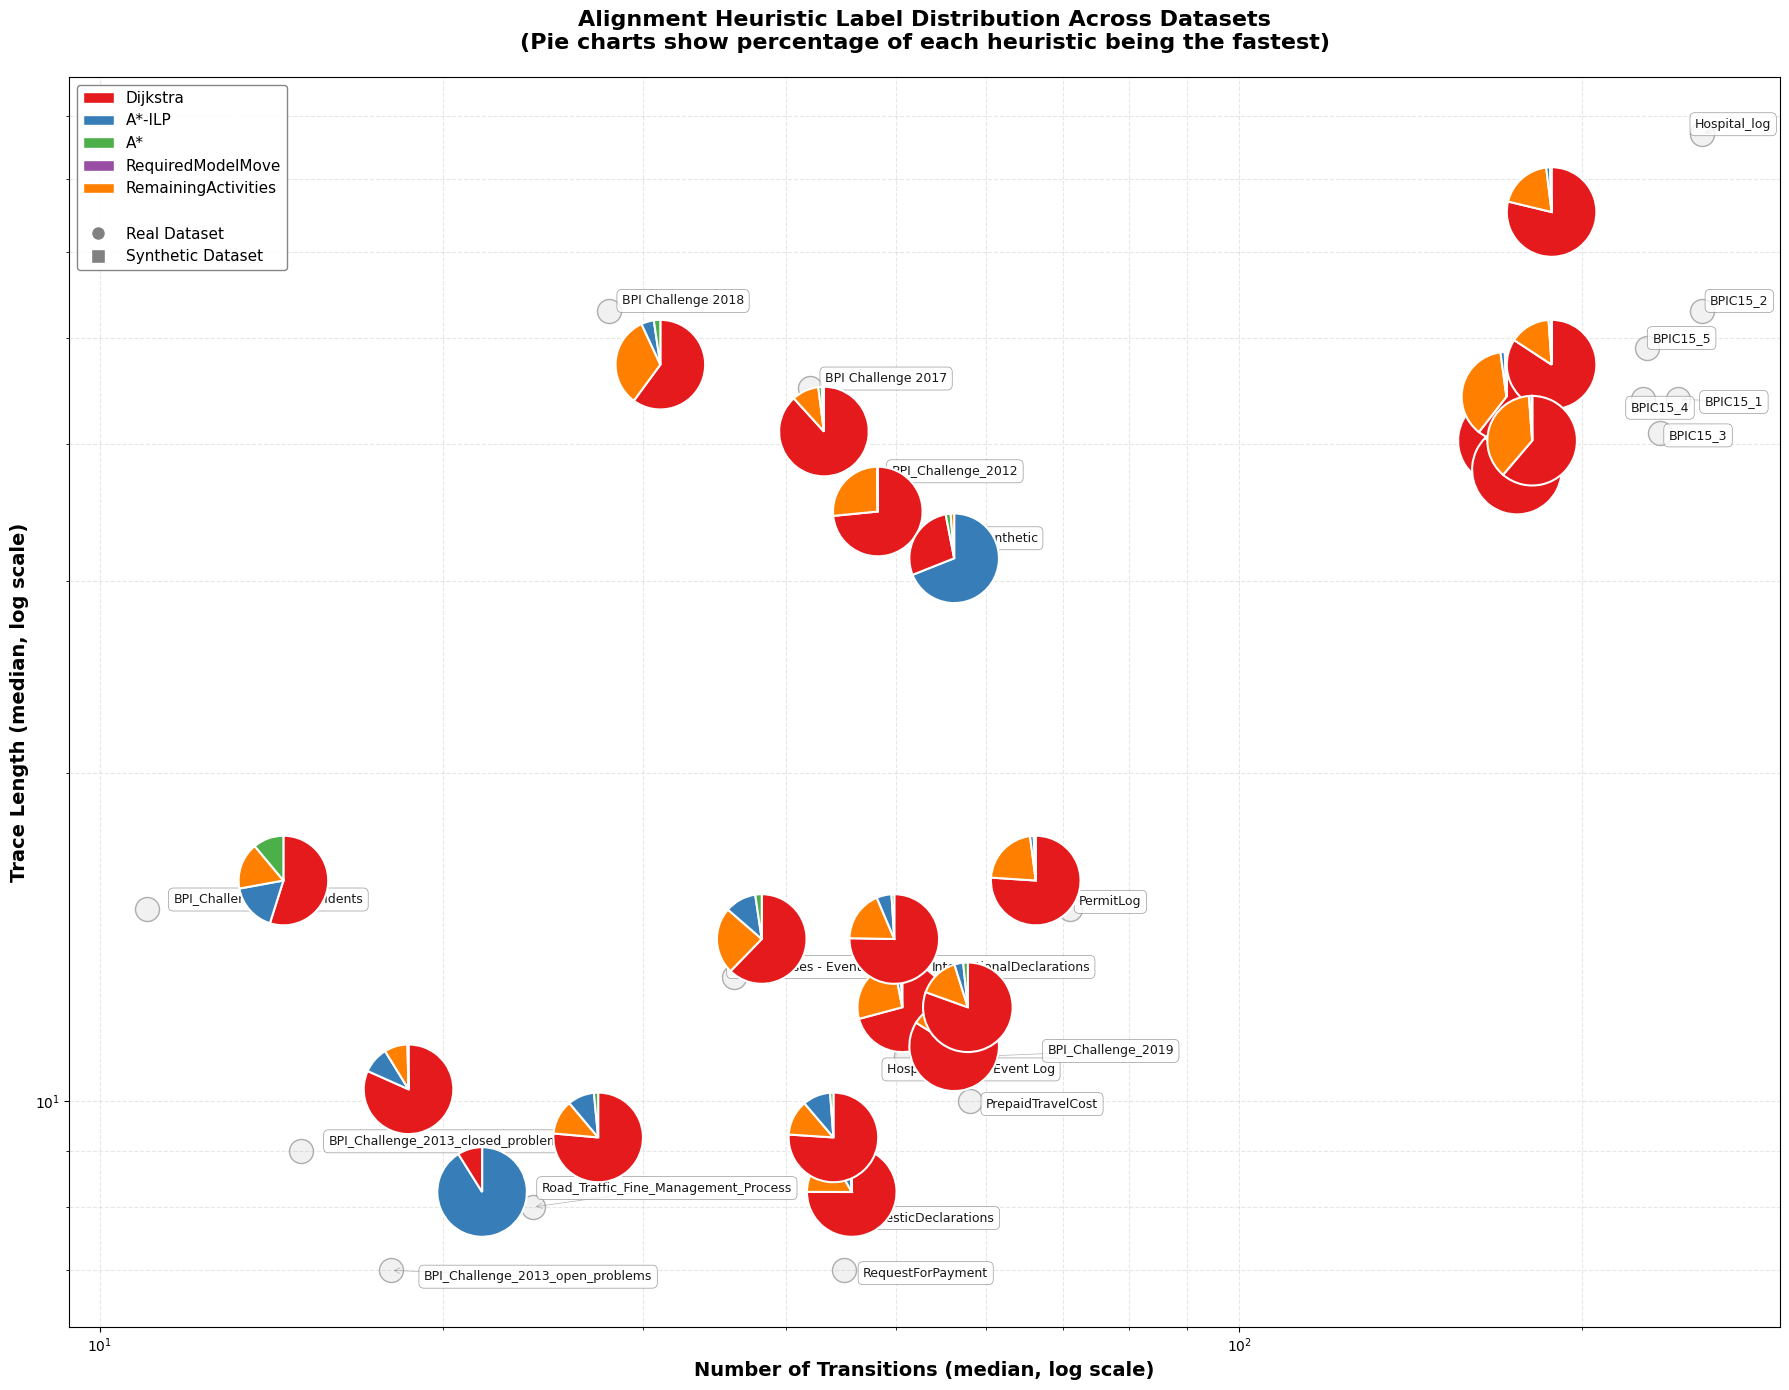


Label Distribution Statistics:

A*:
  Mean: 1.3%
  Median: 0.6%
  Min: 0.0%
  Max: 11.1%
  Std: 2.2%

A*-ILP:
  Mean: 11.4%
  Median: 2.8%
  Min: 0.1%
  Max: 91.1%
  Std: 22.4%

Dijkstra:
  Mean: 69.6%
  Median: 75.7%
  Min: 8.9%
  Max: 88.5%
  Std: 19.0%

RemainingActivities:
  Mean: 17.7%
  Median: 15.8%
  Min: 0.0%
  Max: 37.6%
  Std: 9.8%

RequiredModelMove:
  Mean: 0.0%
  Median: 0.0%
  Min: 0.0%
  Max: 0.0%
  Std: 0.0%


In [33]:
# Create main figure
fig, ax = plt.subplots(figsize=(18, 14))

# Extract data for plotting
names = [r['name'] for r in results]
n_activities = np.array([r['n_unique_activities'] for r in results])
avg_trace_lengths = np.array([r['avg_trace_len'] for r in results])
types = [r['type'] for r in results]

# Debug: Print values
print("Dataset positions:")
for i, name in enumerate(names):
    print(f"  {name}: activities={n_activities[i]}, trace_len={avg_trace_lengths[i]}")

# Set log scale
ax.set_xscale('log')
ax.set_yscale('log')

# Plot background scatter points (to mark positions)
for i, (x, y, dtype) in enumerate(zip(n_activities, avg_trace_lengths, types)):
    marker = 'o' if dtype == 'real' else 's'
    color = 'lightgray'
    ax.scatter(x, y, s=300, c=color, marker=marker, alpha=0.3, zorder=1, edgecolors='black', linewidths=1)

# Plot pie charts at each position
pie_size = 0.08  # Adjust this to change pie chart size
for i, result in enumerate(results):
    position = (n_activities[i], avg_trace_lengths[i])
    plot_pie_at_position(
        ax,
        position,
        result['label_distribution'],
        HEURISTIC_COLORS,
        size=pie_size
    )

# Add dataset name annotations
texts = []
for i, name in enumerate(names):
    text = ax.annotate(
        name,
        (n_activities[i], avg_trace_lengths[i]),
        fontsize=9,
        alpha=0.9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5),
        zorder=5
    )
    texts.append(text)

# Adjust text positions
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.6),
    expand_points=(2.0, 2.0),
    force_text=(0.5, 0.5),
    force_points=(0.3, 0.3),
    ax=ax
)
    
# Axis labels and title
ax.set_xlabel("Number of Transitions (median, log scale)", fontsize=14, fontweight='bold')
ax.set_ylabel("Trace Length (median, log scale)", fontsize=14, fontweight='bold')
ax.set_title(
    "Alignment Heuristic Label Distribution Across Datasets\n" +
    "(Pie charts show percentage of each heuristic being the fastest)",
    fontsize=16,
    fontweight='bold',
    pad=20
)

# Add grid
ax.grid(True, alpha=0.3, linestyle='--', which='both', zorder=0)

# Create legend for heuristics
legend_elements = [
    mpatches.Patch(facecolor=color, edgecolor='white', label=heuristic)
    for heuristic, color in HEURISTIC_COLORS.items()
]
# Add marker legend for dataset types
legend_elements.extend([
    mpatches.Patch(facecolor='none', edgecolor='none', label=''),  # Spacer
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Real Dataset'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='Synthetic Dataset'),
])

ax.legend(
    handles=legend_elements,
    loc='upper left',
    fontsize=11,
    framealpha=0.95,
    edgecolor='gray'
)

plt.tight_layout()
plt.show()

# Print statistics
print("\nLabel Distribution Statistics:")
all_distributions = [r['label_distribution'] for r in results]
all_heuristics = set()
for dist in all_distributions:
    all_heuristics.update(dist.keys())

for heuristic in sorted(all_heuristics):
    percentages = [dist.get(heuristic, 0) for dist in all_distributions]
    print(f"\n{heuristic}:")
    print(f"  Mean: {np.mean(percentages):.1f}%")
    print(f"  Median: {np.median(percentages):.1f}%")
    print(f"  Min: {np.min(percentages):.1f}%")
    print(f"  Max: {np.max(percentages):.1f}%")
    print(f"  Std: {np.std(percentages):.1f}%")

## Alternative: Stacked Bar Chart

Shows label distribution for each dataset as stacked bars.

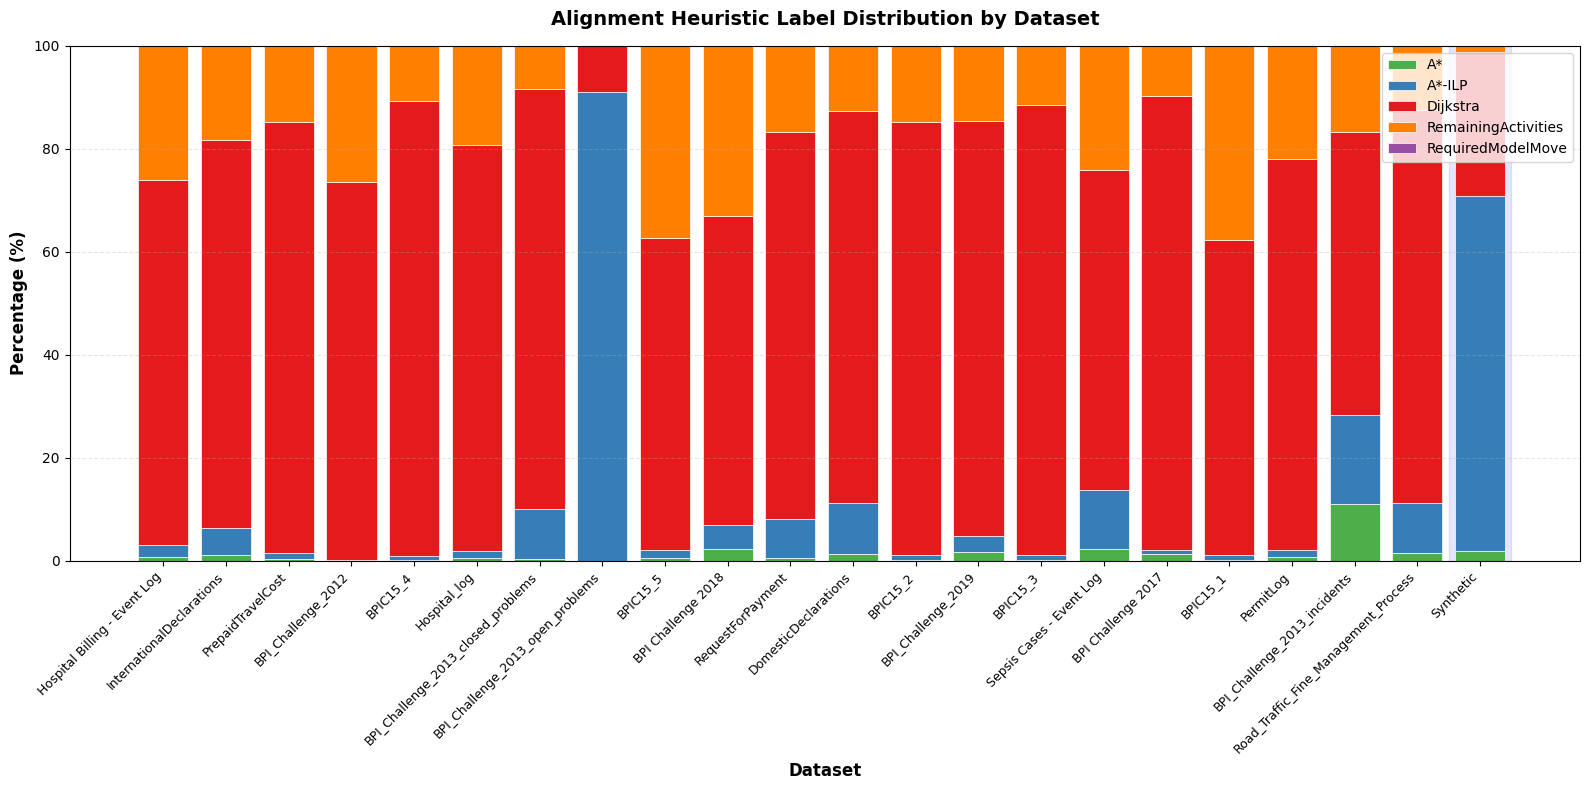

In [34]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(16, 8))

# Prepare data
dataset_names = [r['name'] for r in results]
heuristics = sorted(HEURISTIC_COLORS.keys())

# Build data matrix
data = {h: [] for h in heuristics}
for result in results:
    for h in heuristics:
        data[h].append(result['label_distribution'].get(h, 0))

# Create stacked bars
x = np.arange(len(dataset_names))
width = 0.8
bottom = np.zeros(len(dataset_names))

for heuristic in heuristics:
    values = data[heuristic]
    ax.bar(
        x,
        values,
        width,
        bottom=bottom,
        label=heuristic,
        color=HEURISTIC_COLORS[heuristic],
        edgecolor='white',
        linewidth=0.5
    )
    bottom += values

# Customize
ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_title('Alignment Heuristic Label Distribution by Dataset', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(dataset_names, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Mark synthetic dataset with different background
for i, result in enumerate(results):
    if result['type'] == 'synthetic':
        ax.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='blue', zorder=-1)

plt.tight_layout()
plt.show()